# POOD Dataset Purification EBM vs DM-DDPM

## Neural Tangent

In [79]:
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn'
import json
import numpy as np

df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/From_Scratch/NeuralTangent/POOD.csv')

filters = {
            # 'Baseline':{'Data Key': 'Baseline'},
            # 'JPEG_25':{'Data Key': 'JPEG[25]'},
            'EBM_cinic10_imagenet-1000':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_cinic10_imagenet-750':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_cinic10_imagenet-500':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_cinic10_imagenet-150':{'Data Key': 'EBM[cinic10_imagenet_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_office_home-1000':{'Data Key': 'EBM[office_home_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_office_home-750':{'Data Key': 'EBM[office_home_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_office_home-500':{'Data Key': 'EBM[office_home_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_office_home-150':{'Data Key': 'EBM[office_home_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_textures-1000':{'Data Key': 'EBM[textures_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_textures-750':{'Data Key': 'EBM[textures_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_textures-500':{'Data Key': 'EBM[textures_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_textures-150':{'Data Key': 'EBM[textures_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_lfw_people-1000':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_lfw_people-750':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_lfw_people-500':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_lfw_people-150':{'Data Key': 'EBM[lfw_people_nf[32]]_Steps[150]_T[0.0001]'},
            'EBM_flowers102-1000':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[1000]_T[0.0001]'},
            'EBM_flowers102-750':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[750]_T[0.0001]'},
            'EBM_flowers102-500':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[500]_T[0.0001]'},
            'EBM_flowers102-150':{'Data Key': 'EBM[flowers102_nf[32]]_Steps[150]_T[0.0001]'},
}

df_results = []
for label, filter_dict in filters.items():

    df_filt = df
    for key, value in filter_dict.items():
        if value == 'NaN':
            df_filt = df_filt[df_filt[key].isnull()]
        else:
            df_filt = df_filt[df_filt[key] == value]


    df_results.append({'Defense': label,
                        'Nat Acc': f"{df_filt['End Acc'].mean()*100:.2f} \u00B1 {df_filt['End Acc'].std()*100:.2f}",
                    'Num Results': len(df_filt),
                    })
        
df_results = pd.DataFrame(df_results)
df_results

,Defense,Nat Acc,Num Results
0,EBM_cinic10_imagenet-1000,82.56 ± 0.27,8
1,EBM_cinic10_imagenet-750,82.84 ± 0.32,8
2,EBM_cinic10_imagenet-500,82.04 ± 0.26,8
3,EBM_cinic10_imagenet-150,73.33 ± 0.66,8
4,EBM_office_home-1000,77.73 ± 0.38,8
5,EBM_office_home-750,78.38 ± 0.18,8
6,EBM_office_home-500,78.27 ± 0.37,8
7,EBM_office_home-150,72.25 ± 0.39,8
8,EBM_textures-1000,70.42 ± 0.82,8
9,EBM_textures-750,71.71 ± 0.33,8


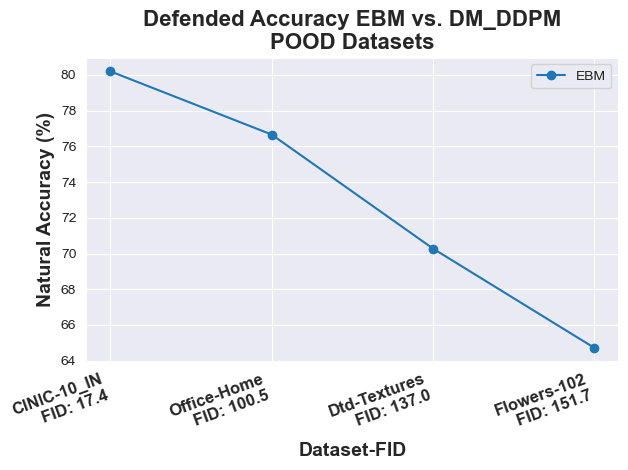

In [100]:
dataset_dict = {
    'cifar10': 'CIFAR-10',
    'cinic10_imagenet': 'CINIC-10_IN',
    'office_home': 'Office-Home',
    'textures': 'Dtd-Textures',
    'lfw_people': 'LFW People',
    'flowers102': 'Flowers-102',
}

dataset_fids = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/Poison_Defense/dataset_FIDs.csv')
dataset_fids['fids'] = dataset_fids['fid_score_mean'].apply(lambda x: float(x.split('±')[0]))

dm_plot = df_results.copy()
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('_')[0])
dm_plot['Dataset'] = dm_plot['Defense'].apply(lambda x: '_'.join(x.split('-')[0].split('_')[1:]))
dm_plot['FIDs'] = dm_plot['Dataset'].apply(lambda x: dataset_fids[dataset_fids['ood_dataset'] == x]['fids'].values[0])
dm_plot['Dataset'] = dm_plot['Dataset'].apply(lambda x: dataset_dict[x])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)
dm_plot['Nat Acc Mean'] = dm_plot['Nat Acc'].apply(lambda x: float(x.split(' ')[0]))

# EBM Plot
dm_plot_ebm = dm_plot[(dm_plot['Steps'] == 500) & (dm_plot['Label'] == 'EBM')]
dm_plot_pivot_ebm = dm_plot.pivot_table(index='Label', columns=['FIDs','Dataset'], values='Nat Acc Mean')
# Combine column levels into one
dm_plot_pivot_ebm.columns = [f'{x[1]}\nFID: {x[0]:.1f}' for x in dm_plot_pivot_ebm.columns]


# Replace X labels with f'{Dataset}-FID:{FID}'
plt.plot(dm_plot_pivot_ebm.columns, dm_plot_pivot_ebm.values[0], marker='o', label='EBM')
# Roate X labels
plt.xticks(rotation=20, ha='right',fontweight='bold',fontsize=12)
plt.ylabel('Natural Accuracy (%)',fontweight='bold',fontsize=14)
plt.xlabel('Dataset-FID',fontweight='bold',fontsize=14)
plt.title('Defended Accuracy EBM vs. DM_DDPM\nPOOD Datasets',fontweight='bold',fontsize=16)
plt.legend()

plt.tight_layout()


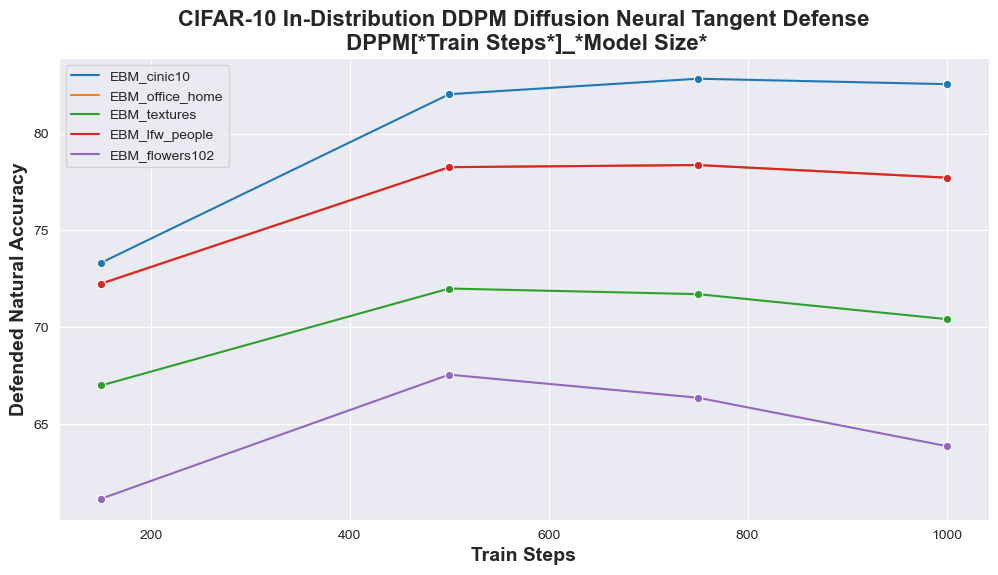

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("darkgrid")

dm_plot = df_results.copy()
dm_plot['Label'] = dm_plot['Defense'].apply(lambda x: x.split('-')[0])
dm_plot['Steps'] = dm_plot['Defense'].apply(lambda x: int(x.split('-')[1]) if len(x.split('-')) > 1 else 0)
dm_plot['Nat Acc Mean'] = dm_plot['Nat Acc'].apply(lambda x: float(x.split(' ')[0]))

# Filter out 0 steps
dm_plot_diff = dm_plot[dm_plot['Steps'] != 0]

# PLot x_axis steps, y axis Nat Acc, and hue as Label
plt.figure(figsize=(12, 6))
sns.lineplot(data=dm_plot_diff, x='Steps', y='Nat Acc Mean', hue='Label', marker='o',palette='tab10')

# # Draw Hlines for EBM and JPEG and No Defense
# plt.axhline(y=dm_plot[dm_plot['Defense'] == 'JPEG_25']['Nat Acc Mean'].values[0], color='r', linestyle='--', label='JPEG')
# plt.axhline(y=dm_plot[dm_plot['Defense'] == 'EBM_1000']['Nat Acc Mean'].values[0], color='g', linestyle='--', label='EBM')

plt.title('CIFAR-10 In-Distribution DDPM Diffusion Neural Tangent Defense\n DPPM[*Train Steps*]_*Model Size*',fontsize=16, fontweight='bold')
plt.xlabel('Train Steps', fontsize=14, fontweight='bold')
plt.ylabel('Defended Natural Accuracy', fontsize=14, fontweight='bold')
plt.legend()

# plt.savefig('CIFAR-10 In-Distribution DDPM Diffusion Neural Tangent Defense.pdf', dpi=300,bbox_inches='tight')